In [1]:
#Import Library
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline


In [2]:
from google.colab import files

# Load CSV file
df = pd.read_csv('DA-task.csv')

##Data Cleaning

In [3]:
df.head()

,ORGANIZATION_ID,ACTIVITY_NAME,TIMESTAMP,CONVERTED,CONVERTED_AT,TRIAL_START,TRIAL_END
0,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.Created,2024-03-27 11:03:53.000,False,NaN,2024-03-27 10:11:39.000,2024-04-26 10:11:39.000
1,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.Created,2024-03-27 11:04:52.000,False,NaN,2024-03-27 10:11:39.000,2024-04-26 10:11:39.000
2,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.Created,2024-03-27 11:04:53.000,False,NaN,2024-03-27 10:11:39.000,2024-04-26 10:11:39.000
3,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.Created,2024-03-27 11:05:18.000,False,NaN,2024-03-27 10:11:39.000,2024-04-26 10:11:39.000
4,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.Created,2024-03-27 11:06:00.000,False,NaN,2024-03-27 10:11:39.000,2024-04-26 10:11:39.000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170526 entries, 0 to 170525
Data columns (total 7 columns):
 #   Column           Non-Null Count   Dtype 
---  ------           --------------   ----- 
 0   ORGANIZATION_ID  170526 non-null  object
 1   ACTIVITY_NAME    170526 non-null  object
 2   TIMESTAMP        170526 non-null  object
 3   CONVERTED        170526 non-null  bool  
 4   CONVERTED_AT     34235 non-null   object
 5   TRIAL_START      170526 non-null  object
 6   TRIAL_END        170526 non-null  object
dtypes: bool(1), object(6)
memory usage: 8.0+ MB


In [5]:
df.shape

(170526, 7)

In [6]:
df.size

1193682

In [7]:
#Removing extra space and organizing our data
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('-', '_')
df.columns

Index(['organization_id', 'activity_name', 'timestamp', 'converted',
       'converted_at', 'trial_start', 'trial_end'],
      dtype='object')

In [8]:
print(df['timestamp'].head())
print(df['timestamp'].dtype)

0    2024-03-27 11:03:53.000
1    2024-03-27 11:04:52.000
2    2024-03-27 11:04:53.000
3    2024-03-27 11:05:18.000
4    2024-03-27 11:06:00.000
Name: timestamp, dtype: object
object


In [27]:
#Working on the datatype
date_cols = ["timestamp", "converted_at", "trial_start", "trial_end"]

for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170526 entries, 0 to 170525
Data columns (total 7 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   organization_id  170526 non-null  object        
 1   activity_name    170526 non-null  object        
 2   timestamp        170526 non-null  datetime64[ns]
 3   converted        170526 non-null  bool          
 4   converted_at     34235 non-null   datetime64[ns]
 5   trial_start      170526 non-null  datetime64[ns]
 6   trial_end        170526 non-null  datetime64[ns]
dtypes: bool(1), datetime64[ns](4), object(2)
memory usage: 8.0+ MB


In [11]:
# Check missing values
print(df.isna().sum())

organization_id         0
activity_name           0
timestamp               0
converted               0
converted_at       136291
trial_start             0
trial_end               0
dtype: int64


In [12]:
# Drop Missing Values
df = df.dropna(subset=['timestamp', 'trial_start', 'trial_end', 'converted'])

In [13]:
# Check missing values
print(df.isna().sum())

organization_id         0
activity_name           0
timestamp               0
converted               0
converted_at       136291
trial_start             0
trial_end               0
dtype: int64


In [14]:
# Numeric summary
df.describe()

# Categorical summary
df.describe(include=['object', 'bool', 'category'])


,organization_id,activity_name,converted
count,170526,170526,170526
unique,966,28,2
top,33f0b98a557961f5ccc519bb972d450f,Scheduling.Shift.Created,False
freq,12136,96895,136291


In [15]:
#Check for Duplicates
df.duplicated().sum()

np.int64(67631)

In [16]:
duplicates = df[df.duplicated()]
duplicates.head()

,organization_id,activity_name,timestamp,converted,converted_at,trial_start,trial_end
153,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.Created,2024-04-17 22:58:40,False,NaT,2024-03-27 10:11:39,2024-04-26 10:11:39
155,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.Created,2024-04-17 22:58:41,False,NaT,2024-03-27 10:11:39,2024-04-26 10:11:39
156,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.Created,2024-04-17 22:58:41,False,NaT,2024-03-27 10:11:39,2024-04-26 10:11:39
195,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.AssignmentChanged,2024-04-19 17:52:03,False,NaT,2024-03-27 10:11:39,2024-04-26 10:11:39
196,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.AssignmentChanged,2024-04-19 17:52:03,False,NaT,2024-03-27 10:11:39,2024-04-26 10:11:39


In [17]:
df[df.duplicated(keep=False)].sort_values(by=['organization_id', 'timestamp']).head(20)

,organization_id,activity_name,timestamp,converted,converted_at,trial_start,trial_end
152,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.Created,2024-04-17 22:58:40,False,NaT,2024-03-27 10:11:39,2024-04-26 10:11:39
153,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.Created,2024-04-17 22:58:40,False,NaT,2024-03-27 10:11:39,2024-04-26 10:11:39
154,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.Created,2024-04-17 22:58:41,False,NaT,2024-03-27 10:11:39,2024-04-26 10:11:39
155,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.Created,2024-04-17 22:58:41,False,NaT,2024-03-27 10:11:39,2024-04-26 10:11:39
156,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.Created,2024-04-17 22:58:41,False,NaT,2024-03-27 10:11:39,2024-04-26 10:11:39
194,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.AssignmentChanged,2024-04-19 17:52:03,False,NaT,2024-03-27 10:11:39,2024-04-26 10:11:39
195,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.AssignmentChanged,2024-04-19 17:52:03,False,NaT,2024-03-27 10:11:39,2024-04-26 10:11:39
196,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.AssignmentChanged,2024-04-19 17:52:03,False,NaT,2024-03-27 10:11:39,2024-04-26 10:11:39
199,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.AssignmentChanged,2024-04-19 17:52:25,False,NaT,2024-03-27 10:11:39,2024-04-26 10:11:39
200,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.AssignmentChanged,2024-04-19 17:52:25,False,NaT,2024-03-27 10:11:39,2024-04-26 10:11:39


In [18]:
#drop duplicates
df = df.drop_duplicates(
    subset=['organization_id', 'activity_name', 'timestamp']
).copy()

## Derived Fields

In [29]:
#Calculate number of days between each activity and the trial start date
df['days_since_trial_start'] = (df['timestamp'] - df['trial_start']).dt.days

# Trial duration (sanity check)
df['trial_duration'] = (df['trial_end'] - df['trial_start']).dt.days

In [30]:
# Time to conversion
df['time_to_convert'] = (df['converted_at'] - df['trial_start']).dt.days

# Early engagement (first 7 days)
df['is_first_week'] = df['days_since_trial_start'] <= 7

Let get to know our data

In [19]:
print("Minimum Date:", df['timestamp'].min())
print("Maximum Date:", df['timestamp'].max())

print(df['timestamp'].dt.year.value_counts())

Minimum Date: 2024-01-01 20:52:26
Maximum Date: 2024-04-28 15:10:31
timestamp
2024    102895
Name: count, dtype: int64


In [20]:
df['activity_name']
print(df['activity_name'].unique())

['Scheduling.Shift.Created' 'Scheduling.Shift.AssignmentChanged'
 'Communication.Message.Created' 'Mobile.Schedule.Loaded'
 'Absence.Request.Created' 'Absence.Request.Approved'
 'Scheduling.Availability.Set' 'Scheduling.Template.ApplyModal.Applied'
 'PunchClockStartNote.Add.Completed' 'PunchClock.PunchedIn'
 'PunchClock.Entry.Edited' 'Scheduling.Shift.Approved'
 'ShiftDetails.View.Opened' 'Absence.Request.Rejected'
 'Scheduling.OpenShiftRequest.Created' 'Scheduling.ShiftSwap.Created'
 'PunchClockEndNote.Add.Completed' 'PunchClock.PunchedOut'
 'Integration.Xero.PayrollExport.Synced'
 'Timesheets.BulkApprove.Confirmed' 'Scheduling.ShiftHandover.Created'
 'Scheduling.ShiftHandover.Accepted' 'Revenue.Budgets.Created'
 'Break.Activate.Started' 'Break.Activate.Finished' 'Shift.View.Opened'
 'Scheduling.OpenShiftRequest.Approved' 'Scheduling.ShiftSwap.Accepted']


In [22]:
df['converted']
print(df['converted'].unique())

[False  True]


In [26]:
df.columns

Index(['organization_id', 'activity_name', 'timestamp', 'converted',
       'converted_at', 'trial_start', 'trial_end'],
      dtype='object')

In [31]:
df['days_since_trial_start']
print(df['days_since_trial_start'].unique())

[ 0 19 21 22 23 24 25 26 27 28 29  1  8  9 10 11 14 15 16 17 18 20  5  6
  7 12 13  3  2  4]


In [32]:
df['time_to_convert']
print(df['time_to_convert'].unique())

[nan 24. 27. 49. 22. 15. 42. 17. 25. 35. 43. 39. 31. 23. 28. 36. 30. 33.
 37. 34. 64. 29. 32. 38. 44. 26. 14. 40. 41. 16. 19. 21. 20. 18. 45. 55.]


In [33]:
df['is_first_week']
print(df['is_first_week'].unique())

[ True False]


### Organization-Level Feature Engineering

To analyze conversion behavior, event-level data was aggregated into organization-level metrics. This allows us to compare engagement patterns between converting and non-converting trialists.

The following features were created:
- Total events: Overall product usage volume
- Active days: Frequency of engagement
- Max active day: Duration of engagement within trial period
- Conversion status: Target variable for analysis

In [36]:
org_df = df.groupby('organization_id').agg({
    'activity_name': 'count',   # total events
    'timestamp': 'nunique',     # active days
    'converted': 'max',         # whether org converted
    'days_since_trial_start': 'max'
}).reset_index()

# Rename columns for clarity and business interpretation
org_df.rename(columns={
    'activity_name': 'total_events',
    'timestamp': 'active_days',
    'days_since_trial_start': 'max_active_day'
}, inplace=True)

org_df.head()

,organization_id,total_events,active_days,converted,max_active_day
0,0040dd9ab132b92d5d04bc3acf14d2e2,1004,997,False,29
1,00456fd86311b6095ad05f7e31758f0d,6,6,False,0
2,007d48a2bc006e6eac0348c788d26dfd,5,5,False,1
3,00d6461845d0042b929379c263e9edef,2,2,False,8
4,00d812389a3cffdbf014ba194cbe922e,586,586,False,29


In [37]:
df.to_csv('clean_dataset_task.csv', index=False)

## Visuals

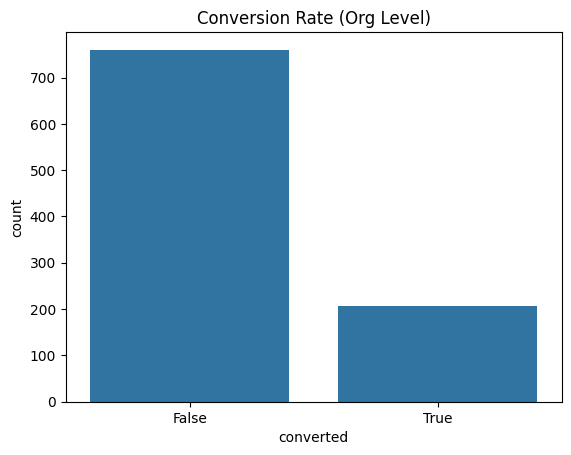

Overall conversion rate: 21.33%


In [38]:
# Conversion Rate
sns.countplot(x='converted', data=org_df)
plt.title("Conversion Rate (Org Level)")
plt.show()

conversion_rate = org_df['converted'].mean()
print(f"Overall conversion rate: {conversion_rate:.2%}")

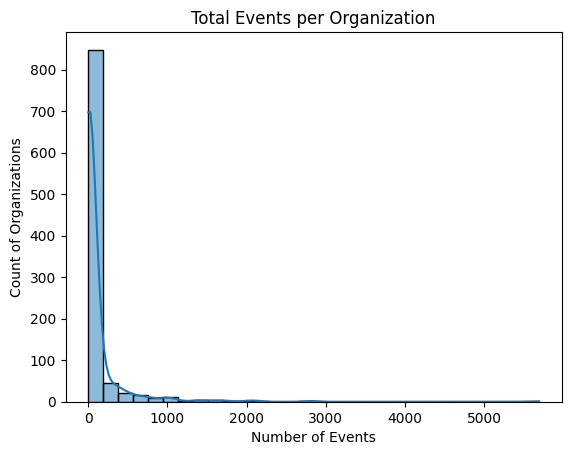

In [53]:
# Distribution of Activity
sns.histplot(org_df['total_events'], bins=30, kde=True)
plt.title("Total Events per Organization")
plt.xlabel("Number of Events")
plt.ylabel("Count of Organizations")
plt.show()

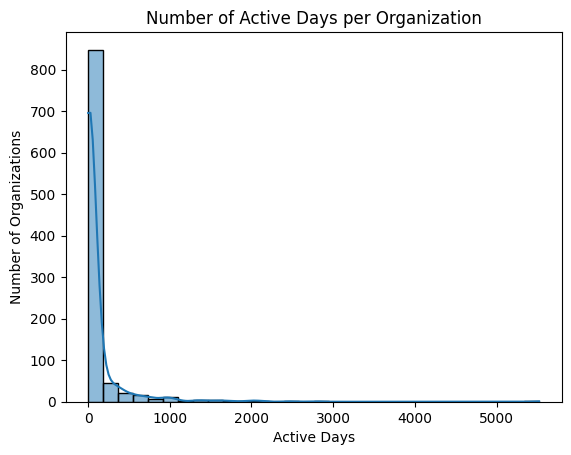

In [55]:
# Active Days Distribution
sns.histplot(org_df['active_days'], bins=30, kde=True)
plt.title("Number of Active Days per Organization")
plt.xlabel("Active Days")
plt.ylabel("Number of Organizations")
plt.show()

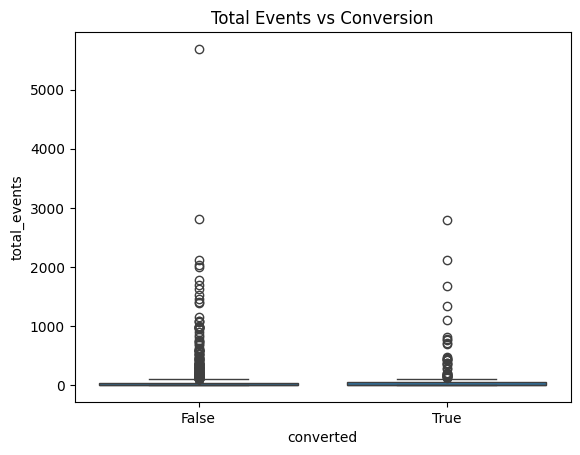

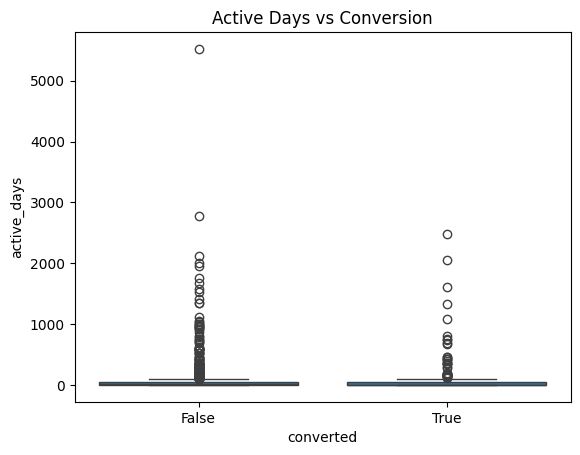

In [45]:
# Events vs Conversion
sns.boxplot(x='converted', y='total_events', data=org_df)
plt.title("Total Events vs Conversion")
plt.show()

sns.boxplot(x='converted', y='active_days', data=org_df)
plt.title("Active Days vs Conversion")
plt.show()

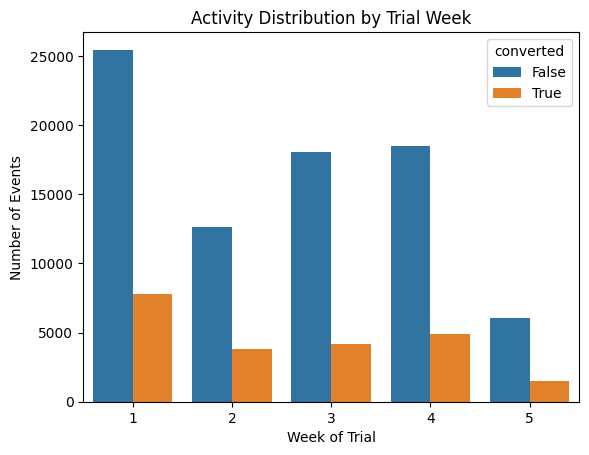

In [46]:
# Timeline of Activity
df['week_of_trial'] = (df['timestamp'] - df['trial_start']).dt.days // 7 + 1
sns.countplot(x='week_of_trial', hue='converted', data=df)
plt.title("Activity Distribution by Trial Week")
plt.xlabel("Week of Trial")
plt.ylabel("Number of Events")
plt.show()

In [58]:
weekly_activity = df.groupby(['week_of_trial', 'converted']).size().reset_index(name='event_count')

weekly_activity

,week_of_trial,converted,event_count
0,1,False,25441
1,1,True,7774
2,2,False,12615
3,2,True,3788
4,3,False,18019
5,3,True,4207
6,4,False,18517
7,4,True,4929
8,5,False,6080
9,5,True,1525


## Summary